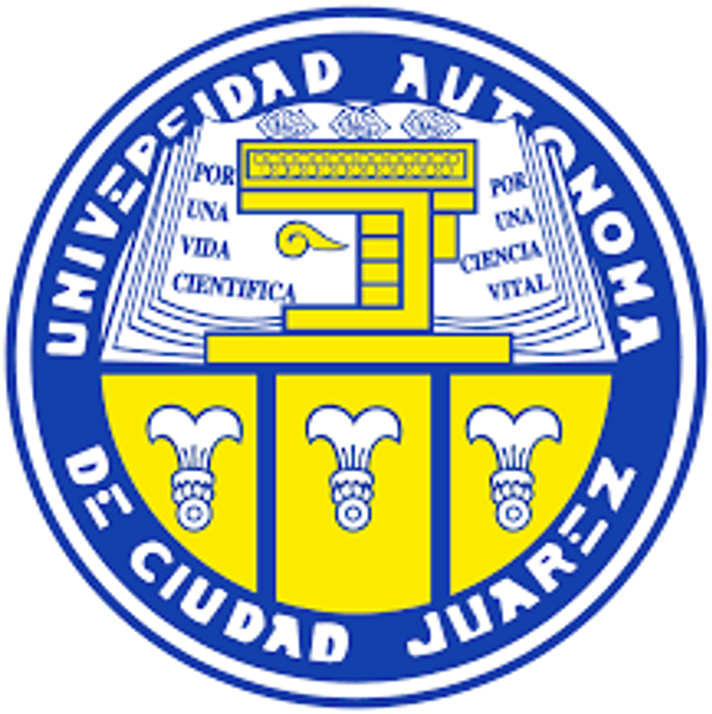


# Titulo: Implementación de una RNN
# Nombre: Sergio Trejo
# Matricula: 261539
# Materia: Redes neuronales profundas_A_Presencial_260206


**Basados en el ejemplo de implementación de una red neuronal recurrente compartido en el archivo Ejemplo RNN imdb, realice los siguientes experimentos:**
 * Replique los resultados obtenidos.
 * Modifique la red neuronal recurrente simple por una capa LSTM dejando los mismos parámetros. Solo cambie la línea "layers.SimpleRNN(64)" por "layers.LSTM(64)" .
 * A continuación, cambie la red LSTM por una GRU. Solo cambie la línea "layers.LSTM(64)" por  "layers.GRU(64)" . 

  1. Registre el desempeño de las redes con el conjunto de prueba y presente las curvas de entrenamiento: Accuracy vs. epochs y Loss vs. epochs, de los conjuntos de entrenamiento y validación. 

   2. Registre el tiempo de entrenamiento por época que tomaron en promedio cada una de las redes.


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences #Permite estandarizar los casos de las frases que se van a analizar, para que todas tengan la misma longitud antes de que entren a la red neuronal.
import time


2026-03-07 22:25:48.982610: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-07 22:25:48.995395: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-07 22:25:49.436558: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-07 22:25:50.921509: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computat

## 1. Replicar resultados con RNN Simple

In [2]:
#Parametros del modelo
VOCAB_SIZE   = 10000     # top palabras
MAX_LEN      = 200       # longitud fija de secuencia

# Cargar el dataset de IMDB
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

# Padding / truncado para longitud fija
x_train = pad_sequences(x_train,
                         maxlen=MAX_LEN,  # longitud fija de la secuencia
                         padding="pre",  # agregar ceros al inicio de la secuencia de ser demasiado corta
                         truncating="pre" # eliminar palabras al inicio de la secuencia si es demasiado larga, elimina todas las palabras anteriores a la longitud máxima, dejando solo las últimas palabras de la secuencia
                         )
x_test  = pad_sequences(x_test,  maxlen=MAX_LEN, padding="pre", truncating="pre")

print(f"Train: {x_train.shape},  Test: {x_test.shape}")




Train: (25000, 200),  Test: (25000, 200)


In [3]:
#%%

rnn_model = keras.Sequential([
        keras.layers.Input(shape=(MAX_LEN,), dtype='int32'),
        keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128),
        layers.SimpleRNN(64),                     # RNN básica
        layers.Dense(1, activation="sigmoid")     # binaria
])
rnn_model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
] #Detiene el entrenamiento si la pérdida de validación no mejora durante 5 épocas consecutivas, restaurando los pesos del modelo al mejor estado encontrado durante el entrenamiento.

rnn_model.summary() 

print("Parametros totales:", rnn_model.count_params())

E0000 00:00:1772947554.190828    4649 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772947554.198922    4649 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

Parametros totales: 1292417


In [4]:
start = time.time()

hist_rnn = rnn_model.fit(
    x_train, y_train,
    validation_split=0.15,
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    verbose=2
)

end = time.time()

#Calcular el tiempo promedio de entrenamiento por época
epoch_time = (end - start) / len(hist_rnn.history['loss'])

print(f"Tiempo promedio por epoca: {epoch_time:.2f} segundos")

rnn_test_loss, rnn_test_acc = rnn_model.evaluate(x_test, y_test, verbose=0)
print(f"[SimpleRNN] Test acc: {rnn_test_acc:.4f} | loss: {rnn_test_loss:.4f}")





Epoch 1/10
333/333 - 7s - 21ms/step - accuracy: 0.5918 - loss: 0.6572 - val_accuracy: 0.7229 - val_loss: 0.5398
Epoch 2/10
333/333 - 6s - 18ms/step - accuracy: 0.7468 - loss: 0.5118 - val_accuracy: 0.8035 - val_loss: 0.4548
Epoch 3/10
333/333 - 6s - 18ms/step - accuracy: 0.8752 - loss: 0.3035 - val_accuracy: 0.7968 - val_loss: 0.4559
Epoch 4/10
333/333 - 6s - 17ms/step - accuracy: 0.9148 - loss: 0.2156 - val_accuracy: 0.8184 - val_loss: 0.5011
Epoch 5/10
333/333 - 6s - 18ms/step - accuracy: 0.9720 - loss: 0.0841 - val_accuracy: 0.7773 - val_loss: 0.6391
Epoch 6/10
333/333 - 6s - 18ms/step - accuracy: 0.9957 - loss: 0.0201 - val_accuracy: 0.7605 - val_loss: 0.7784
Epoch 7/10
333/333 - 6s - 17ms/step - accuracy: 0.9996 - loss: 0.0050 - val_accuracy: 0.7739 - val_loss: 0.8780
Tiempo promedio por epoca: 6.09 segundos
[SimpleRNN] Test acc: 0.7983 | loss: 0.4646


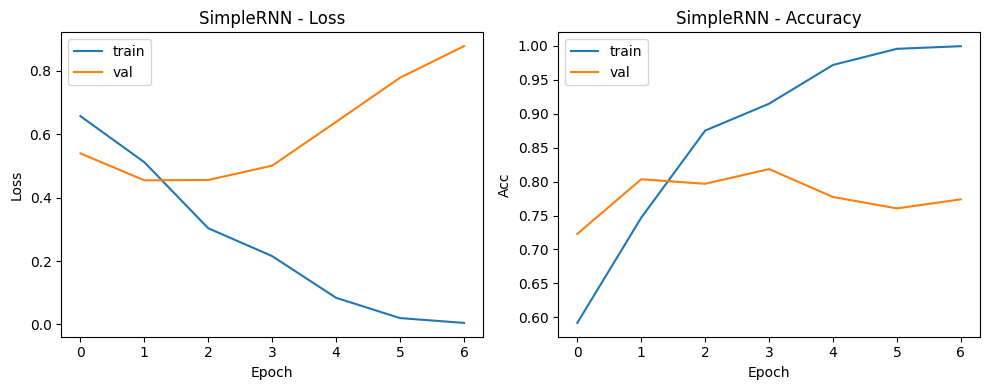

SimpleRNN -> Test acc: 0.7983 | Test loss: 0.4646


In [5]:
def plot_history(hist, title):
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    ax[0].plot(hist.history["loss"], label="train")
    ax[0].plot(hist.history["val_loss"], label="val")
    ax[0].set_title(f"{title} - Loss"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].legend()
    ax[1].plot(hist.history["accuracy"], label="train")
    ax[1].plot(hist.history["val_accuracy"], label="val")
    ax[1].set_title(f"{title} - Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Acc"); ax[1].legend()
    plt.tight_layout(); plt.show()

#Graficar la historia de entrenamiento
plot_history(hist_rnn, "SimpleRNN")

print(f"SimpleRNN -> Test acc: {rnn_test_acc:.4f} | Test loss: {rnn_test_loss:.4f}")


**Conclusion**

* La RNN simple aprender muy rapido el conjunto de entrenamiento, llegando cerca del 100% de accuracy, pero el desempeño en validacion se mantiene alrededor del 78 - 81%. Esto quiere decir que la red se esta sobreajustando ya que memoriza los datos de entrenamiento pero no generaliza igual de bien los datos nuevos.
* El loss de entrenamiento disminuye constantemente, mientras el loss de validacion aumenta con las epocas, lo cual es otra señal clara de overfitting en el modelo.
* Estos resultados muestran que aunque la RNN simple logra aprender patrones del texto, su capacidad para generalizar es algo limitada. 
* Este modelo tiene aproximadamente 1.29 millones de parametros entrenables. Aunque se definieron 10 epocas, el entrenamiento se detuvo antes debido al uso de EarlyStopping, que monitorea la perdida de validacion y detiene el entrenamiento cuando esta deja de mejorar durante varias epocas consecutivas. El tiempo promedio por epoca fue de 6 segundos.


## 2. Modificar la red neuronal recurrente simple por una capa LSTM dejando los mismos parámetros.

In [6]:
#%%

rnn_model = keras.Sequential([
        keras.layers.Input(shape=(MAX_LEN,), dtype='int32'),
        keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128),
        layers.LSTM(64),                     # RNN LSTM
        layers.Dense(1, activation="sigmoid")     # binaria
])
rnn_model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
] #Detiene el entrenamiento si la pérdida de validación no mejora durante 5 épocas consecutivas, restaurando los pesos del modelo al mejor estado encontrado durante el entrenamiento.

rnn_model.summary() 

print("Parametros totales:", rnn_model.count_params())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

Parametros totales: 1329473


In [7]:
start = time.time()

hist_rnn = rnn_model.fit(
    x_train, y_train,
    validation_split=0.15,
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    verbose=2
)

end = time.time()

#Calcular el tiempo promedio de entrenamiento por época
epoch_time = (end - start) / len(hist_rnn.history['loss'])

print(f"Tiempo promedio por epoca: {epoch_time:.2f} segundos")

rnn_test_loss, rnn_test_acc = rnn_model.evaluate(x_test, y_test, verbose=0)
print(f"[LSTM] Test acc: {rnn_test_acc:.4f} | loss: {rnn_test_loss:.4f}")

Epoch 1/10
333/333 - 13s - 39ms/step - accuracy: 0.8045 - loss: 0.4151 - val_accuracy: 0.8624 - val_loss: 0.3162
Epoch 2/10
333/333 - 12s - 37ms/step - accuracy: 0.8980 - loss: 0.2574 - val_accuracy: 0.8675 - val_loss: 0.3699
Epoch 3/10
333/333 - 37s - 111ms/step - accuracy: 0.9364 - loss: 0.1720 - val_accuracy: 0.8685 - val_loss: 0.3494
Epoch 4/10
333/333 - -12s - -36244us/step - accuracy: 0.9544 - loss: 0.1279 - val_accuracy: 0.8541 - val_loss: 0.3725
Epoch 5/10
333/333 - 13s - 38ms/step - accuracy: 0.9603 - loss: 0.1126 - val_accuracy: 0.8597 - val_loss: 0.4442
Epoch 6/10
333/333 - 13s - 38ms/step - accuracy: 0.9749 - loss: 0.0730 - val_accuracy: 0.8325 - val_loss: 0.4757
Tiempo promedio por epoca: 12.67 segundos
[LSTM] Test acc: 0.8650 | loss: 0.3149


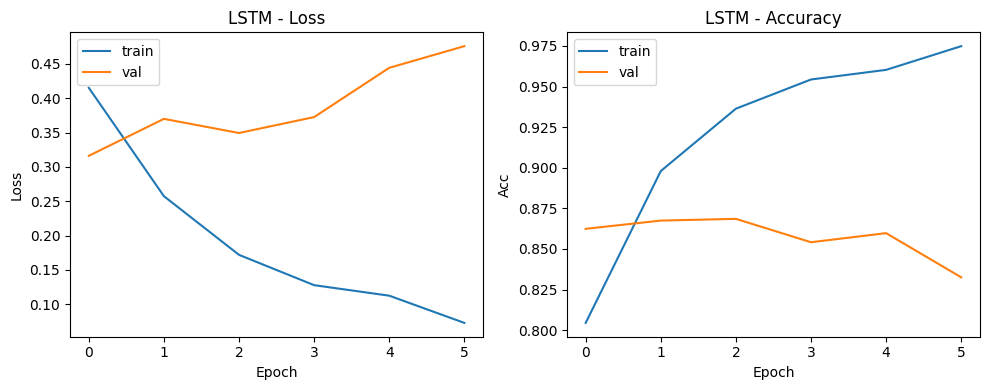

LSTM -> Test acc: 0.8650 | Test loss: 0.3149


In [8]:
# Graficar historia de entrenamiento

plot_history(hist_rnn, "LSTM")

print(f"LSTM -> Test acc: {rnn_test_acc:.4f} | Test loss: {rnn_test_loss:.4f}")

**Conclusion**

* El modelo LSTM aprende rapidamente el conjunto de entrenamiento, el accuracy de train sube de aproximadamente 0.75 a casi 0.98 en pocas epocas. Sin embargo, el accuracy de validacion se mantiene alrededor de 0.85, lo que indica que aunque el modelo aprende bien, tambien comienza a aparecer overfitting despues de algunas epocas.
* En la grafica de loss se observa que la perdida de entrenamiento sigue disminuyendo con las epocas, mientras que la loss de validacion comienza a aumentar despues de la segunda o tercera epoca. Esto tambien es un indicio el modelo empieza a memorizar el dataset de entrenamiento y no generaliza bien. 
* El modelo alcanza un test accuracy de 0.8650, lo que indica que le LSTM captura mejor las dependencias en el texto que una RNN simple, aunque el costo computacional es mayor, con un tiempo promedio de entrenamiento de aproximadamente 12.67 segundos por epoca.
* Este modelo tiene aproximadamente 1.31 millones de parametros entrenables, ligeramente mas que la RNN simple. Tambien el entrenamiento se detuvo en la epoca 7, aunque se definieron 10 epocas, debido al mecanismo de EarlyStopping, que evita continuar entrenando cuando la perdida de validacion deja de mejorar.

## 3. Modificar la red LSTM por una GRU. 

In [9]:

rnn_model = keras.Sequential([
        keras.layers.Input(shape=(MAX_LEN,), dtype='int32'),
        keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128),
        layers.GRU(64),                     # RNN GRU
        layers.Dense(1, activation="sigmoid")     # binaria
])
rnn_model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
] #Detiene el entrenamiento si la pérdida de validación no mejora durante 5 épocas consecutivas, restaurando los pesos del modelo al mejor estado encontrado durante el entrenamiento.

rnn_model.summary() 


print("Parametros totales:", rnn_model.count_params())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,313 (5.03 MB)

 Trainable params: 1,317,313 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

Parametros totales: 1317313


In [10]:
start = time.time()

hist_rnn = rnn_model.fit(
    x_train, y_train,
    validation_split=0.15,
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    verbose=2
)

end = time.time()

#Calcular el tiempo promedio de entrenamiento por época
epoch_time = (end - start) / len(hist_rnn.history['loss'])

print(f"Tiempo promedio por epoca: {epoch_time:.2f} segundos")


rnn_test_loss, rnn_test_acc = rnn_model.evaluate(x_test, y_test, verbose=0)
print(f"[GRU] Test acc: {rnn_test_acc:.4f} | loss: {rnn_test_loss:.4f}")

Epoch 1/10
333/333 - 15s - 44ms/step - accuracy: 0.7737 - loss: 0.4529 - val_accuracy: 0.7997 - val_loss: 0.4561
Epoch 2/10
333/333 - 14s - 41ms/step - accuracy: 0.8828 - loss: 0.2863 - val_accuracy: 0.8664 - val_loss: 0.3327
Epoch 3/10
333/333 - 13s - 40ms/step - accuracy: 0.9297 - loss: 0.1848 - val_accuracy: 0.8629 - val_loss: 0.3363
Epoch 4/10
333/333 - 14s - 41ms/step - accuracy: 0.9536 - loss: 0.1290 - val_accuracy: 0.8413 - val_loss: 0.4153
Epoch 5/10
333/333 - 13s - 40ms/step - accuracy: 0.9661 - loss: 0.0949 - val_accuracy: 0.8421 - val_loss: 0.4181
Epoch 6/10
333/333 - 14s - 42ms/step - accuracy: 0.9778 - loss: 0.0675 - val_accuracy: 0.8589 - val_loss: 0.5169
Epoch 7/10
333/333 - 13s - 40ms/step - accuracy: 0.9852 - loss: 0.0471 - val_accuracy: 0.8525 - val_loss: 0.6645
Tiempo promedio por epoca: 13.69 segundos
[GRU] Test acc: 0.8610 | loss: 0.3375


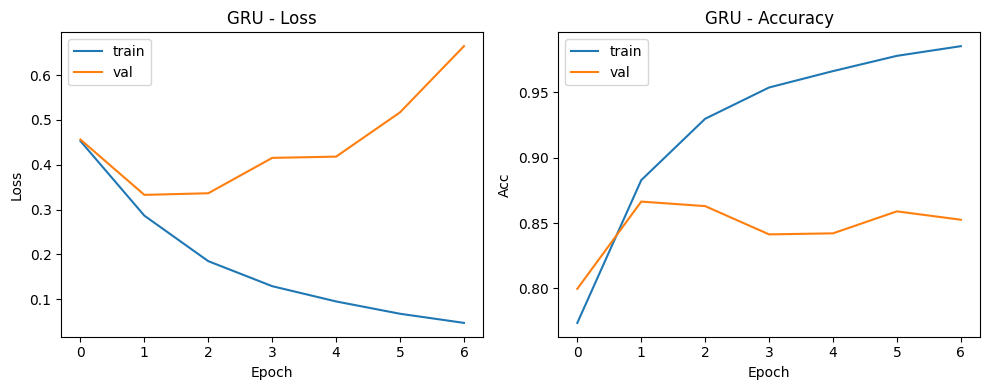

GRU -> Test acc: 0.8610 | Test loss: 0.3375


In [11]:
#Graficar la historia de entrenamiento
plot_history(hist_rnn, "GRU")

print(f"GRU -> Test acc: {rnn_test_acc:.4f} | Test loss: {rnn_test_loss:.4f}")

**Conclusion**
* Al comparar las tres arquitecturas, GRU obtuvo un test accuracy de 0.8610, abajo de LSTM con 0.8650, mientras que SimpleRNN obtuvo el menor accuracy. Esto muestra que las arquitecturas con mecanismos de memoria como LSTM y GRU pueden capturar mejor las relaciones en secuencias de texto.
* En la grafica de loss se observa que la perdida de entrenamiento sigue disminuyendo continuamente, mientras que la loss de validacion comienza a aumentar despues de las primeras epocas. Esto sugiere que el modelo empieza a memorizar los datos de entrenamiento y ya no mejora su capacidad de generalizacion.
* A pesar de esto, el modelo logra un test accuracy de 0.8610, que es ligeramente menor que el obtenido con LSTM en este experimento. El tiempo promedio de entrenamiento fue de aproximadamente 13.69 segundos por epoca, lo que muestra que GRU tiene un costo computacional similar al de LSTM. 
* GRU tiene aproximadamente 1.32 millones de parametros entrenables. Al igual que en los otros modelos, el entrenamiento se detuvo en la epoca 7 por el EarlyStopping